## PART A: Probabilistic Guassian Generative Classifier
### Importing Python Libraries 
They are imported for data handling, visualization, machine learning, and evaluation:
- `load_digits` dataset, a common dataset for classification tasks involving handwritten numbers.
-  `seaborn` is a statistical data-visualization library built on top of Matplotlib.  
It provides advanced visualizations (heatmaps, distributions, styling) with minimal code.
- `numpy` for numerical operations and data manipulation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

This GaussianGenerativeClassifier implements a simple generative classifier that models each class by a multivariate Gaussian (normal) distribution with the same covariance matrix for every class.
- This is the classic Linear Discriminant Analysis (LDA) style model:
- For each class k it models 𝑝(𝑥∣𝑦=𝑘)=𝑁(𝑥;𝜇_𝑘,Σ)
- Class prior is p(y=k)=π_k.
- The covariance Σ is shared across classes (not class-specific).
- Prediction chooses the class with the largest posterior probability 𝑝(𝑦=𝑘∣𝑥), which reduces to comparing linear discriminant scores because covariance is shared.  

`__init__(self, lambda_reg=1e-3)`:
- lambda_reg is a regularization parameter for covariance matrix (λ)
- class_priors: array of estimated priors π_k.
- class_means: matrix of class means μ_k (one mean per class)
- classes: array of unique classes
- shared_cov : estimated shared covariance Σ.

`fit(self, X, y)`: It estimated parameters from training data
- X : array-like, shape (n_samples, n_features) displaying the training data
- y : array-like, shape (n_samples,) displaying the training labels
- It estimates class priors 𝜋_𝑘=(#samples with class 𝑘)/(𝑛_samples) as empirial priors (frequency based)
- It estimates class means μ_k.
- It calculates shared covariance, because we average over all samples (not per-class), covariance is pooled (shared).
- It regularizes covariance ensure positive definiteness and prevent singularity (if Σ is badly conditioned or rank-deficient).

`predict_log_proba(self, X)`:
- it gives the likeliness of the sample to belong to this class for each sample and each class but it returns log probabilities instead of probabilities.
1. How likely is the class itself is defined by class prior log π_k
2. How likely is the class's Gaussian fit the sample logp(x∣y=k)
3. Add them together logp(y=k∣x) ∝ logπ_k ​+ logp(x∣y=k)
4. It returns a matrix with probability of each sample in each class (log_probs)

The Mahalanobis distance answers how unsual the sample is from belonging to class k and is more accurate than calculating the normal distance:
- small distance, good fit --> sits near the mean
- large distance, bad fit --> far away from the mean  
The actual log-likelihood will be high for small Mahalonobis distance and low for large Mahalanobis distance

`predict(self, X)`:
- It calls `predict_log_proba(X)` and picks class with largest unnormalized log posterior per sample and returns array of predicted class labels


In [2]:

class GaussianGenerativeClassifier:
    def __init__(self, lambda_reg=1e-3):
        self.lambda_reg = lambda_reg
        self.class_priors = None
        self.class_means = None
        self.shared_cov = None
        self.classes = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        
        # 1. Estimate class priors π_k
        self.class_priors = np.zeros(n_classes)
        for idx, k in enumerate(self.classes):
            self.class_priors[idx] = np.sum(y == k) / n_samples
        
        # 2. Estimate class means μ_k
        self.class_means = np.zeros((n_classes, n_features))
        for idx, k in enumerate(self.classes):
            self.class_means[idx] = np.mean(X[y == k], axis=0)
        
        # 3. Estimate shared covariance matrix Σ
        cov_sum = np.zeros((n_features, n_features))
        for i in range(n_samples):
            # Find which class this sample belongs to
            class_idx = np.where(self.classes == y[i])[0][0]
            # Compute (x_i - μ_{y_i})
            diff = X[i] - self.class_means[class_idx]
            # Accumulate outer product
            cov_sum += np.outer(diff, diff)
        
        # Average over all samples
        self.shared_cov = cov_sum / n_samples
        
        # 4. Regularize covariance: Σ_λ = Σ + λI
        self.shared_cov += self.lambda_reg * np.eye(n_features)
        
    def predict_log_proba(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))
        
        # Compute inverse and log determinant once
        cov_inv = np.linalg.inv(self.shared_cov)
        log_det = np.linalg.slogdet(self.shared_cov)[1]
        
        for idx, k in enumerate(self.classes):
            # Log prior
            log_prior = np.log(self.class_priors[idx])
            
            # Log likelihood: log N(x; μ_k, Σ)
            # log N(x; μ, Σ) = -0.5 * [d*log(2π) + log|Σ| + (x-μ)ᵀΣ⁻¹(x-μ)]
            #how far the sample from the mean of class x is
            diff = X - self.class_means[idx]
            mahalanobis = np.sum(diff @ cov_inv * diff, axis=1)
            log_likelihood = -0.5 * (log_det + mahalanobis)
            
            # Log posterior (unnormalized)
            log_probs[:, idx] = log_prior + log_likelihood
        
        return log_probs
    
    def predict(self, X):
        log_probs = self.predict_log_proba(X)
        class_indices = np.argmax(log_probs, axis=1)
        return self.classes[class_indices]



#### **Dataset Loading:**
- This splits the data into rain (70%), validation (15%) and test set (15%).
- It prints the basic dataset info like size, number of classes, number of samples per class
- It standardizes the features as pixels across images vary in intensity and standardizing helps the model learn better


In [3]:
def load_and_split_data():
    """
    Load digits dataset and create 70/15/15 train/val/test split.
    """
    # Load dataset
    digits = load_digits()
    X, y = digits.data, digits.target
    
    print(f"Dataset shape: {X.shape}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Class distribution: {np.bincount(y)}")
    
    # First split: 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
    
    # Second split: 15% validation, 15% test (from the 30% temp)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
    
    print(f"\nTrain set size: {X_train.shape[0]}")
    print(f"Validation set size: {X_val.shape[0]}")
    print(f"Test set size: {X_test.shape[0]}")
    
    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    return X_train, X_val, X_test, y_train, y_val, y_test



#### **Hyperparameter Tuning:**
It tries different values of lambda λ and chooses the best one.
Lambda controls **regularization** of the covariance matrix.
- Less reglarization --> model may overfit
- More regularization --> model may underfit

It does the following for **each lambda:**
1. Train a classifier with that lambda
2. Predict on the validation set
3. Compute validation accuracy
4. Save the result

Lastly, it chooses the Lambda with the highest accuracy

In [4]:
def hyperparameter_tuning(X_train, y_train, X_val, y_val, lambda_values):
    """
    Tune λ hyperparameter using validation set.
    """
    results = []
    
    print("\n" + "="*60)
    print("HYPERPARAMETER TUNING")
    print("="*60)
    
    for lambda_reg in lambda_values:
        clf = GaussianGenerativeClassifier(lambda_reg=lambda_reg)
        clf.fit(X_train, y_train)
        y_val_pred = clf.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)
        
        results.append({
            'lambda': lambda_reg,
            'validation_accuracy': val_acc
        })
        
        print(f"λ = {lambda_reg:.1e}: Validation Accuracy = {val_acc:.4f}")
    
    # Find best lambda
    best_result = max(results, key=lambda x: x['validation_accuracy'])
    best_lambda = best_result['lambda']
    
    print(f"\nBest λ: {best_lambda:.1e}")
    print(f"Best Validation Accuracy: {best_result['validation_accuracy']:.4f}")
    
    return best_lambda, results


#### **Evaluate Final Model()**
- It trains the model using the train and validation sets together
- Evaluate once on the test set
- Compute detailed metrics such as accuracy, precision, recall and f1 score 
- It gives the confusion matrix the true and predicted labels for the test set

In [5]:
def evaluate_final_model(X_train, X_val, X_test, y_train, y_val, y_test, best_lambda):
    """
    Train final model on train+val and evaluate on test set.
    """
    print("\n" + "="*60)
    print("FINAL MODEL EVALUATION")
    print("="*60)
    
    # Combine train and validation sets
    X_train_combined = np.vstack([X_train, X_val])
    y_train_combined = np.hstack([y_train, y_val])
    
    print(f"Combined training set size: {X_train_combined.shape[0]}")
    
    # Train final model
    clf = GaussianGenerativeClassifier(lambda_reg=best_lambda)
    clf.fit(X_train_combined, y_train_combined)
    
    # Predict on test set
    y_test_pred = clf.predict(X_test)
    
    # Calculate metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_test_pred, average='macro', zero_division=0
    )
    
    print(f"\nTest Accuracy: {test_acc:.4f}")
    print(f"Macro-averaged Precision: {precision:.4f}")
    print(f"Macro-averaged Recall: {recall:.4f}")
    print(f"Macro-averaged F1-score: {f1:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    
    return {
        'accuracy': test_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'predictions': y_test_pred
    }


#### **Plotting the confusion matrix and analyzing the confusion**
- It displays the confusion matrix with colors using Seaboarn 
- It prints the top 10 most confused digit pairs by:
1- Looping through off diagonal matrix cells
2- If misclassification exists --> record (true, predicted, count)
3- It sorts by count (largest first)
4- Prints the top confusions

In [6]:
def plot_confusion_matrix(cm, title='Confusion Matrix'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def analyze_confusion(cm):
    """
    Analyze which digits are most confused with each other.
    """
    print("\n" + "="*60)
    print("CONFUSION ANALYSIS")
    print("="*60)
    
    # Find top confusions (off-diagonal elements)
    confusions = []
    for i in range(10):
        for j in range(10):
            if i != j and cm[i, j] > 0:
                confusions.append((i, j, cm[i, j]))
    
    # Sort by confusion count
    confusions.sort(key=lambda x: x[2], reverse=True)
    
    print("\nTop 10 Digit Confusions:")
    print(f"{'True':<6} {'Predicted':<10} {'Count':<6}")
    print("-" * 30)
    for i, (true_label, pred_label, count) in enumerate(confusions[:10]):
        print(f"{true_label:<6} {pred_label:<10} {count:<6}")



PART A: GAUSSIAN GENERATIVE CLASSIFIER
Dataset shape: (1797, 64)
Number of classes: 10
Class distribution: [178 182 177 183 181 182 181 179 174 180]

Train set size: 1257
Validation set size: 270
Test set size: 270

HYPERPARAMETER TUNING
λ = 1.0e-04: Validation Accuracy = 0.9444
λ = 1.0e-03: Validation Accuracy = 0.9444
λ = 1.0e-02: Validation Accuracy = 0.9444
λ = 1.0e-01: Validation Accuracy = 0.9444

Best λ: 1.0e-04
Best Validation Accuracy: 0.9444

FINAL MODEL EVALUATION
Combined training set size: 1527

Test Accuracy: 0.9630
Macro-averaged Precision: 0.9632
Macro-averaged Recall: 0.9627
Macro-averaged F1-score: 0.9625

CONFUSION MATRIX

Confusion Matrix (rows=true, cols=predicted):
[[27  0  0  0  0  0  0  0  0  0]
 [ 0 26  0  0  0  0  0  0  1  1]
 [ 0  0 26  0  0  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0]
 [ 0  0  0  0  0 27  0  0  0  0]
 [ 0  0  0  0  0  0 27  0  0  0]
 [ 0  0  0  0  0  0  0 27  0  0]
 [ 0  3  0  0  0  0  0  0 22  1]
 [ 0  1

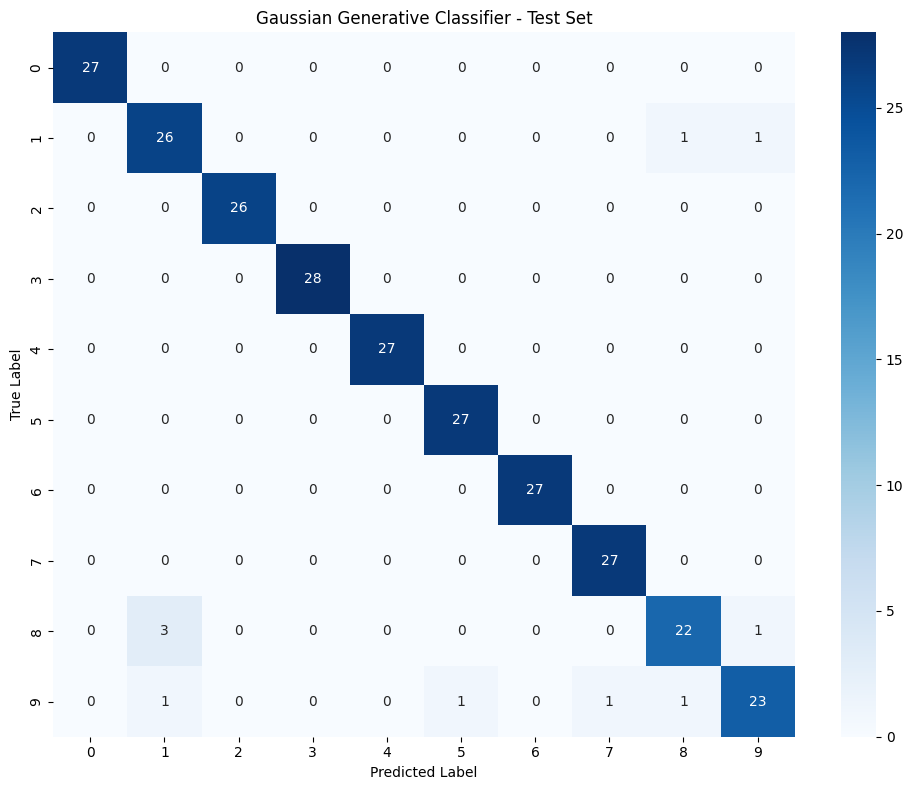


EXECUTION COMPLETE


In [7]:
# Main execution
if __name__ == "__main__":
    print("="*60)
    print("PART A: GAUSSIAN GENERATIVE CLASSIFIER")
    print("="*60)
    
    # Load and split data
    X_train, X_val, X_test, y_train, y_val, y_test = load_and_split_data()
    
    # Define lambda values to test
    lambda_values = [1e-4, 1e-3, 1e-2, 1e-1]
    
    # Hyperparameter tuning
    best_lambda, tuning_results = hyperparameter_tuning(
        X_train, y_train, X_val, y_val, lambda_values
    )
    
    # Final evaluation
    results = evaluate_final_model(
        X_train, X_val, X_test, y_train, y_val, y_test, best_lambda
    )
    
    # Print confusion matrix
    print("\n" + "="*60)
    print("CONFUSION MATRIX")
    print("="*60)
    print("\nConfusion Matrix (rows=true, cols=predicted):")
    print(results['confusion_matrix'])
    
    # Analyze confusions
    analyze_confusion(results['confusion_matrix'])
    
    # Plot confusion matrix
    plot_confusion_matrix(results['confusion_matrix'], 
                         'Gaussian Generative Classifier - Test Set')
    
    print("\n" + "="*60)
    print("EXECUTION COMPLETE")
    print("="*60)

## SUMMARY OF PART A
**1. Explanation of the Generative Model used**
Assumptions of the model
In a Gaussian generative classifier, we model:
- Class prior p(y=k) = π_k : the probability of each digit appearing in the dataset.
- Class mean μ_k: Compute the average pixel vector of all samples belonging to class 𝑘
- Class-conditional distribution p(x∣y=k)=N(x;μ_k, Σ): This assumes that every digit class k has its own mean vector 
- All classes share the same covariance matrix Σ

This means the classifier assumes that:
Each digit class forms an ellipsoid-shaped Gaussian cluster in feature space.
All clusters have identical shape (same covariance), but different centers.

**2. Regularization**
- Regularization Σ + λI is needed as the covariance matrix can become:nearly singular (non-invertible), noisy because of limited samples, numerically unstable and this is fixed by the regularization.
- Lambda controls **regularization** of the covariance matrix.
  -  Less reglarization --> model may overfit
  - More regularization --> model may underfit

**3. Most Common confusions**
- Digit 8 is confused with 1 and 9 which makes sense as in low resolution, 8 may be identified as a straight line like 1 or have a rounded shape like 9 in its upper half
- Digit 9 is confused with 1, 5, 7, 8 for the similarities between them with 9 or the different styles it could be written with.
But overall, confusion is very minimal meaning the model is very accurate.

**4. Choosing different Lambdas and their Effect**
- In our results, the dataset is stable which is why the different lambdas didn't have an impact on the predictions and all had an accuracy of 0.9444.

**5. Strengths and Weaknesses of this Gaussian Generative Model**
- Strengths:
  - It is very fast to train
  - High accuracy for the test set
- Weaknesses:
  - It assumes all classes share the same covariance which is unrealistic
  - The digits dataset is not truly Gaussian — some digits (like 8, 9) have multimodal shapes.
  - Struggles with digits that have similar pixel structures at low resolution.
